# Convinience Functions

In [24]:
import hyrax
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import logging
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering, OPTICS, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [25]:
def extract_umap_info(x,y,base_directory="/mmfs1/gscratch/dirac/aritrag/hyrax_comcam_dp1_runs"):
  """Extract UMAP directory from 3dumap output file."""
  import re
  
  # Construct paths
  run_dir = Path(base_directory) / f"run{x}"
  dumap_name = f"udb{x}_{y}"

  dumap_output_file = run_dir / f"{dumap_name}.txt"
  dumap_toml_file = run_dir / f"{dumap_name}.toml"
    
  try:
      with open(dumap_output_file, 'r') as f:
          content = f.read()

      # Look for the UMAP results save pattern
      pattern = r'Saving UMAP results to (.+)'
      match = re.search(pattern, content)

      if match:
          umap_dir = match.group(1).strip()
          return umap_dir, dumap_toml_file
      else:
          raise ValueError(f"Could not find UMAP directory in {dumap_output_file}")

  except FileNotFoundError:
      raise FileNotFoundError(f"3dumap output file not found: {dumap_output_file}")

In [26]:
def plot_umap_clusters(ax, config=None, input_dir=None, 
                      clustering_method='kmeans', n_clusters=8,
                      clustering_params=None, 
                      alpha=0.6, s=5, cmap='tab10',
                      show_cluster_centers=False, show_metrics=True,
                      title=None, supress_hyrax_logs=False):
    """
    Create a matplotlib scatter plot of 2D UMAP results with clustering overlay.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to plot on
    config: 
        Hyrax config object
    input_dir : str or Path, optional
        Directory containing UMAP results. If None, uses most recent in current results dir.
    clustering_method : str, default 'kmeans'
        Clustering algorithm to use ('kmeans' or 'dbscan')
    n_clusters : int, default 8
        Number of clusters for KMeans (ignored for DBSCAN)
    clustering_params : dict, optional
        Additional parameters to pass to clustering algorithm
    alpha : float, default 0.6
        Point transparency
    s : float, default 5
        Point size
    cmap : str, default 'tab10'
        Colormap name (discrete colormap recommended for clusters)
    show_cluster_centers : bool, default False
        Whether to show cluster centers (KMeans only)
    show_metrics : bool, default True
        Whether to display clustering metrics in title
    title : str, optional
        Custom plot title
    supress_hyrax_logs : bool, default False
        Whether to suppress hyrax logging output
        
    Returns
    -------
    dict
        Dictionary containing:
        - 'ax': The matplotlib axis object
        - 'labels': Cluster labels for each point
        - 'centers': Cluster centers (if applicable)
        - 'metrics': Dictionary of clustering metrics
    """
    
    from hyrax.data_sets.inference_dataset import InferenceDataSet
    
    # Load UMAP results
    if supress_hyrax_logs:
        logging.disable(logging.CRITICAL)
    umap_results = InferenceDataSet(config, results_dir=input_dir, verb="umap")
    logging.disable(logging.NOTSET)
    
    # Extract 2D coordinates
    points = np.array([point.numpy() for point in umap_results])
    x, y = points[:, 0], points[:, 1]
    
    # Set up clustering parameters
    if clustering_params is None:
        clustering_params = {}
    
    # Perform clustering
    cluster_labels, cluster_centers, metrics = apply_clustering(
        points, clustering_method, n_clusters, **clustering_params
    )
    
    # Create scatter plot colored by cluster
    scatter = ax.scatter(x, y, c=cluster_labels, alpha=alpha, s=s, cmap=cmap)
    
    # Add cluster centers if requested and available
    if show_cluster_centers and cluster_centers is not None:
        ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
                  c='red', marker='x', s=100, linewidths=3, label='Centers')
        ax.legend()
    
    # Add colorbar for cluster labels
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Cluster')
    
    # Set title with metrics if requested
    if title is None:
        title_parts = [f'{clustering_method.upper()} Clustering']
        if show_metrics and metrics:
            if 'silhouette_score' in metrics:
                title_parts.append(f"Silhouette: {metrics['silhouette_score']:.3f}")
            if 'n_clusters' in metrics:
                title_parts.append(f"Clusters: {metrics['n_clusters']}")
        title = ' | '.join(title_parts)
    
    ax.set_title(title)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    return {
        'ax': ax,
        'labels': cluster_labels,
        'centers': cluster_centers,
        'metrics': metrics
    }

## Different Clustering Functions 

In [27]:
def apply_kmeans_clustering(data, n_clusters=8, **params):
    """
    Apply KMeans clustering to 2D UMAP data.
    
    Parameters
    ----------
    data : np.ndarray
        2D array of UMAP coordinates (n_samples, 2)
    n_clusters : int, default 8
        Number of clusters
    **params : dict
        Additional parameters for KMeans
        
    Returns
    -------
    tuple
        (cluster_labels, cluster_centers, metrics)
    """
    # Set default parameters for KMeans
    kmeans_params = {
        'n_clusters': n_clusters,
        'random_state': 42,
        'n_init': 10
    }
    kmeans_params.update(params)
    
    clusterer = KMeans(**kmeans_params)
    cluster_labels = clusterer.fit_predict(data)
    cluster_centers = clusterer.cluster_centers_
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found,
        'inertia': clusterer.inertia_
    }
    
    return cluster_labels, cluster_centers, metrics

In [28]:
def apply_dbscan_clustering(data, eps=0.5, min_samples=5, **params):
    """
    Apply DBSCAN clustering to 2D UMAP data.
    
    Parameters
    ----------
    data : np.ndarray
        2D array of UMAP coordinates (n_samples, 2)
    eps : float, default 0.5
        Maximum distance between samples for them to be considered neighbors
    min_samples : int, default 5
        Minimum number of samples in a neighborhood for a point to be core
    **params : dict
        Additional parameters for DBSCAN
        
    Returns
    -------
    tuple
        (cluster_labels, cluster_centers, metrics)
    """
    # Set default parameters for DBSCAN
    dbscan_params = {
        'eps': eps,
        'min_samples': min_samples
    }
    dbscan_params.update(params)
    
    clusterer = DBSCAN(**dbscan_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers for each cluster (excluding noise)
    unique_labels = np.unique(cluster_labels)
    valid_clusters = unique_labels[unique_labels != -1]  # Exclude noise points (-1)
    
    cluster_centers = None
    if len(valid_clusters) > 0:
        cluster_centers = []
        for cluster_id in valid_clusters:
            cluster_mask = cluster_labels == cluster_id
            cluster_points = data[cluster_mask]
            # Calculate coordinate-wise median
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
        cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    n_clusters_found = len(valid_clusters)
    n_noise = np.sum(cluster_labels == -1)
    
    metrics = {
        'n_clusters': n_clusters_found,
        'n_noise_points': n_noise,
        'noise_fraction': n_noise / len(cluster_labels)
    }
    
    # Calculate silhouette score only if we have more than 1 cluster
    if n_clusters_found > 1:
        # Exclude noise points for silhouette calculation
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette_avg = silhouette_score(
                data[non_noise_mask], 
                cluster_labels[non_noise_mask]
            )
            metrics['silhouette_score'] = silhouette_avg
    
    return cluster_labels, cluster_centers, metrics

In [29]:
def apply_hdbscan_clustering(data, min_cluster_size=5, min_samples=None, **params):
    """Apply HDBSCAN clustering to 2D UMAP data."""
    hdbscan_params = {
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples
    }
    hdbscan_params.update(params)
    
    clusterer = HDBSCAN(**hdbscan_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers (excluding noise)
    unique_labels = np.unique(cluster_labels)
    valid_clusters = unique_labels[unique_labels != -1]
    
    cluster_centers = None
    if len(valid_clusters) > 0:
        cluster_centers = []
        for cluster_id in valid_clusters:
            cluster_mask = cluster_labels == cluster_id
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
        cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    n_clusters_found = len(valid_clusters)
    n_noise = np.sum(cluster_labels == -1)
    
    metrics = {
        'n_clusters': n_clusters_found,
        'n_noise_points': n_noise,
        'noise_fraction': n_noise / len(cluster_labels)
    }
    
    if n_clusters_found > 1:
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette_avg = silhouette_score(data[non_noise_mask], cluster_labels[non_noise_mask])
            metrics['silhouette_score'] = silhouette_avg
    
    return cluster_labels, cluster_centers, metrics

In [30]:
def apply_gmm_clustering(data, n_components=8, **params):
    """Apply Gaussian Mixture Model clustering to 2D UMAP data."""
    gmm_params = {
        'n_components': n_components,
        'random_state': 42
    }
    gmm_params.update(params)
    
    clusterer = GaussianMixture(**gmm_params)
    clusterer.fit(data)
    cluster_labels = clusterer.predict(data)
    cluster_centers = clusterer.means_  # GMM has explicit means
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found,
        'aic': clusterer.aic(data),
        'bic': clusterer.bic(data)
    }
    
    return cluster_labels, cluster_centers, metrics

In [31]:
def apply_spectral_clustering(data, n_clusters=8, **params):
    """Apply Spectral clustering to 2D UMAP data."""
    spectral_params = {
        'n_clusters': n_clusters,
        'random_state': 42
    }
    spectral_params.update(params)
    
    clusterer = SpectralClustering(**spectral_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers
    cluster_centers = []
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        if np.any(cluster_mask):
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
    cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found
    }
    
    return cluster_labels, cluster_centers, metrics

In [32]:
def apply_agglomerative_clustering(data, n_clusters=8, **params):
    """Apply Agglomerative clustering to 2D UMAP data."""
    agg_params = {
        'n_clusters': n_clusters,
        'linkage': 'ward'
    }
    agg_params.update(params)
    
    clusterer = AgglomerativeClustering(**agg_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers
    cluster_centers = []
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        if np.any(cluster_mask):
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
    cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found
    }
    
    return cluster_labels, cluster_centers, metrics

In [33]:
def apply_optics_clustering(data, min_samples=5, xi=0.05, **params):
    """Apply OPTICS clustering to 2D UMAP data."""
    optics_params = {
        'min_samples': min_samples,
        'xi': xi,
        'cluster_method': 'xi'
    }
    optics_params.update(params)
    
    clusterer = OPTICS(**optics_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers (excluding noise)
    unique_labels = np.unique(cluster_labels)
    valid_clusters = unique_labels[unique_labels != -1]
    
    cluster_centers = None
    if len(valid_clusters) > 0:
        cluster_centers = []
        for cluster_id in valid_clusters:
            cluster_mask = cluster_labels == cluster_id
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
        cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    n_clusters_found = len(valid_clusters)
    n_noise = np.sum(cluster_labels == -1)
    
    metrics = {
        'n_clusters': n_clusters_found,
        'n_noise_points': n_noise,
        'noise_fraction': n_noise / len(cluster_labels)
    }
    
    if n_clusters_found > 1:
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette_avg = silhouette_score(data[non_noise_mask], cluster_labels[non_noise_mask])
            metrics['silhouette_score'] = silhouette_avg
    
    return cluster_labels, cluster_centers, metrics

#### Clustering Dispatcher Function

In [34]:
def apply_clustering(data, method='kmeans', n_clusters=8, **params):
    """
    Apply clustering algorithm to 2D UMAP data (dispatcher function).
    
    Parameters
    ----------
    data : np.ndarray
        2D array of UMAP coordinates (n_samples, 2)
    method : str, default 'kmeans'
        Clustering method: 'kmeans', 'dbscan', 'hdbscan', 'gmm', 'spectral', 'agglomerative', 'optics'
    n_clusters : int, default 8
        Number of clusters for methods that require it (ignored for density-based methods)
    **params : dict
        Additional parameters for clustering algorithm
        
    Returns
    -------
    tuple
        (cluster_labels, cluster_centers, metrics)
    """
    
    if method == 'kmeans':
        return apply_kmeans_clustering(data, n_clusters=n_clusters, **params)
    elif method == 'dbscan':
        return apply_dbscan_clustering(data, **params)
    elif method == 'hdbscan':
        return apply_hdbscan_clustering(data, **params)
    elif method == 'gmm':
        return apply_gmm_clustering(data, n_components=n_clusters, **params)
    elif method == 'spectral':
        return apply_spectral_clustering(data, n_clusters=n_clusters, **params)
    elif method == 'agglomerative':
        return apply_agglomerative_clustering(data, n_clusters=n_clusters, **params)
    elif method == 'optics':
        return apply_optics_clustering(data, **params)
    else:
        supported_methods = ['kmeans', 'dbscan', 'hdbscan', 'gmm', 'spectral', 'agglomerative', 'optics']
        raise ValueError(f"Unsupported clustering method: {method}. Supported methods: {supported_methods}")

## Example of Different Clustering Methods

![Different Clustering Methods](https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png)

## run4

[2025-07-23 16:46:06,197 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.
[2025-07-23 16:46:06,198 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.
[2025-07-23 16:46:06,198 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.
[2025-07-23 16:46:06,203 hyrax:INFO] Runtime Config read from: /mmfs1/gscratch/dirac/aritrag/hyrax_comcam_dp1_runs/run4/udb4_12.toml


Running clustering methods:   0%|          | 0/5 [00:00<?, ?it/s]

Running KMEANS clustering...
Running DBSCAN clustering...
Running HDBSCAN clustering...
Running OPTICS clustering...
Running SPECTRAL clustering...


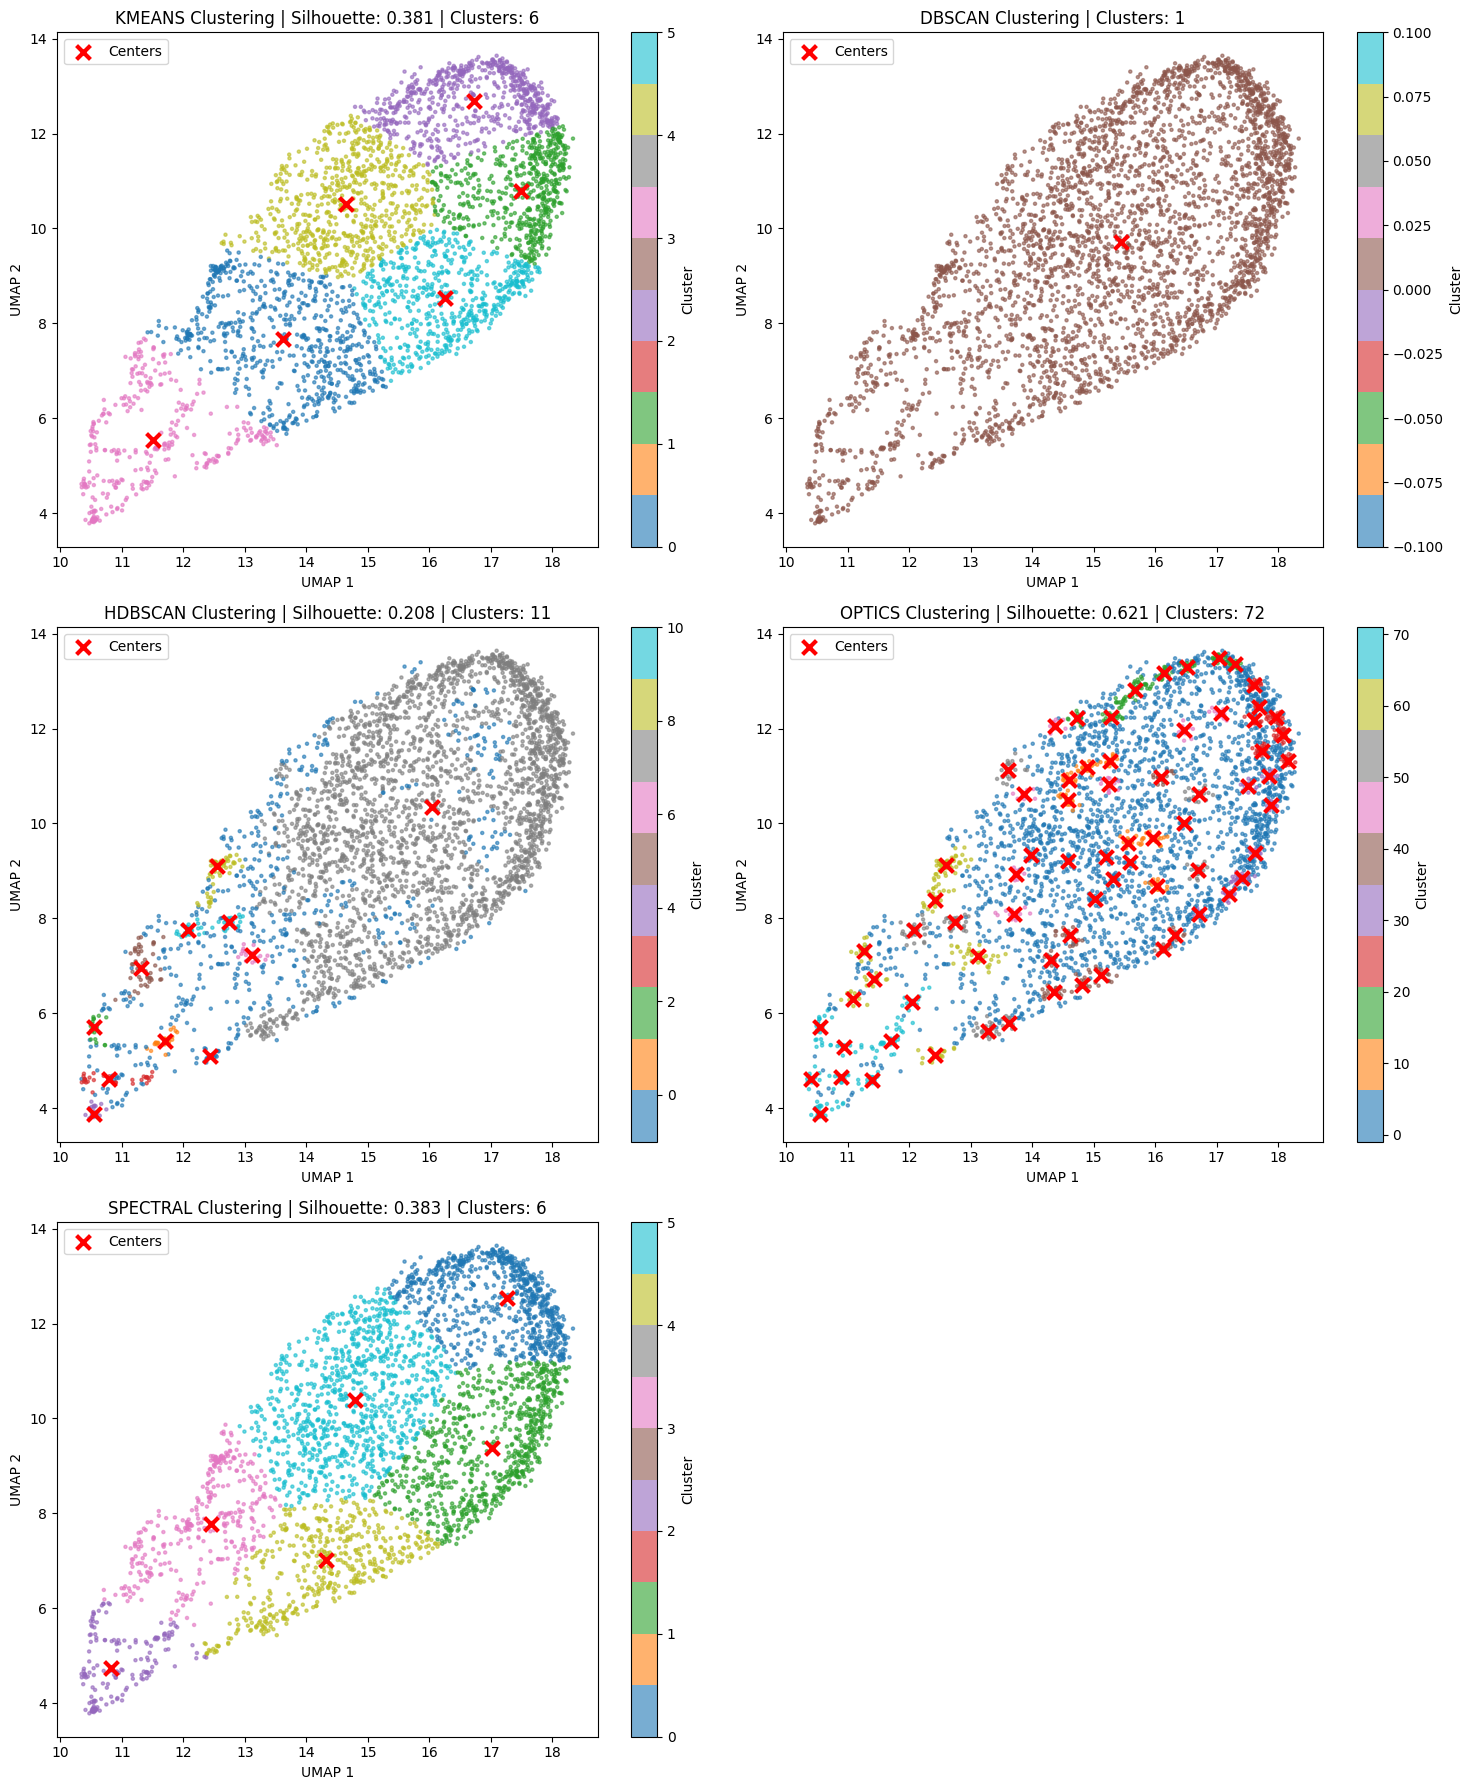

In [37]:
# Test with run 4, experiment 12 data - Compare all clustering methods
from tqdm.notebook import tqdm

run = 4
expt = 12

# Get UMAP info and create hyrax config
umap_dir, config_file = extract_umap_info(run, expt)
h = hyrax.Hyrax(config_file=config_file)

# Create subplot grid (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

# Define clustering methods and their parameters
clustering_configs = [
    ('kmeans', 6, {}, True),  # method, n_clusters, extra_params, show_centers
    ('dbscan', None, {'eps': 0.5, 'min_samples': 10}, True),
    ('hdbscan', None, {'min_cluster_size': 15}, True),
    ('optics', None, {'min_samples': 10, 'xi': 0.05, 'max_eps': 2.0}, True),
    ('spectral', 6, {}, True)
]

results = {}

# Plot each clustering method
for i, (method, n_clusters, params, show_centers) in enumerate(tqdm(clustering_configs, desc="Running clustering methods")):
    if i < len(axes):
        print(f"Running {method.upper()} clustering...")
        
        result = plot_umap_clusters(
            axes[i], 
            config=h.config, 
            input_dir=umap_dir,
            clustering_method=method,
            n_clusters=n_clusters if n_clusters is not None else 8,  # Default for methods that need it
            clustering_params=params,
            show_cluster_centers=show_centers,
            supress_hyrax_logs=True
        )
        
        results[method] = result

# Hide the last unused subplot
if len(clustering_configs) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [38]:
# Print summary of all results
print("\n" + "="*50)
print("CLUSTERING COMPARISON SUMMARY")
print("="*50)

for method, result in results.items():
    print(f"\n{method.upper()}:")
    print(f"  Clusters: {result['metrics']['n_clusters']}")
    
    if 'silhouette_score' in result['metrics']:
        print(f"  Silhouette Score: {result['metrics']['silhouette_score']:.3f}")
    
    if 'n_noise_points' in result['metrics']:
        print(f"  Noise Points: {result['metrics']['n_noise_points']}")
        print(f"  Noise Fraction: {result['metrics']['noise_fraction']:.3f}")
    
    if 'inertia' in result['metrics']:
        print(f"  Inertia: {result['metrics']['inertia']:.1f}")
    
    if 'aic' in result['metrics']:
        print(f"  AIC: {result['metrics']['aic']:.1f}")
        print(f"  BIC: {result['metrics']['bic']:.1f}")


CLUSTERING COMPARISON SUMMARY

KMEANS:
  Clusters: 6
  Silhouette Score: 0.381
  Inertia: 4101.9

DBSCAN:
  Clusters: 1
  Noise Points: 0
  Noise Fraction: 0.000

HDBSCAN:
  Clusters: 11
  Silhouette Score: 0.208
  Noise Points: 524
  Noise Fraction: 0.155

OPTICS:
  Clusters: 72
  Silhouette Score: 0.621
  Noise Points: 2057
  Noise Fraction: 0.607

SPECTRAL:
  Clusters: 6
  Silhouette Score: 0.383
